# SilkRoute Benchmark — 01: Generation Sanity & Core Pattern Verification
Validates scale, referential integrity, and key benchmark narratives.

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = "../silkroute_benchmark_out"  # adjust if needed

with open(f"{OUT}/seed_manifest.json","r", encoding="utf-8") as f:
    manifest = json.load(f)

def load_table(name):
    return pd.read_parquet(f"{OUT}/{name}.parquet")

channels = load_table("channels")
stores = load_table("stores")
salespeople = load_table("salespeople")
customers = load_table("customers")
products = load_table("products")
skus = load_table("product_variants_skus")
variant_attributes = load_table("variant_attributes")
cat_attr_defs = load_table("category_attribute_definitions")
promotions = load_table("promotions")
transactions = load_table("transactions")
lines = load_table("transaction_lines")
inventory = load_table("inventory_snapshots")
returns = load_table("returns")

transactions["transaction_ts"] = pd.to_datetime(transactions["transaction_ts"])
transactions["month"] = transactions["transaction_ts"].dt.to_period("M").astype(str)

lines = lines.merge(
    transactions[["transaction_id","transaction_ts","month","channel_type","store_id","customer_id","salesperson_id"]],
    on="transaction_id", how="left"
)
lines = lines.merge(skus[["sku_id","product_id","base_price"]], on="sku_id", how="left")
lines = lines.merge(products[["product_id","category","subcategory","brand"]], on="product_id", how="left")

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
promotions["start_date"] = pd.to_datetime(promotions["start_date"])
promotions["end_date"] = pd.to_datetime(promotions["end_date"])

hero_skus = set(manifest["pattern_sets"].get("hero_skus", []))
high_return_skus = set(manifest["pattern_sets"].get("high_return_skus", []))
top_salespeople = set(manifest["people_sets"].get("top_salespeople", []))
discount_heavy_salespeople = set(manifest["people_sets"].get("discount_heavy_salespeople", []))
underperforming_stores = set(manifest["meta"].get("underperforming_stores", []))
discount_heavy_stores = set(manifest["meta"].get("discount_heavy_stores", []))

def pct(x):
    return 100.0 * x


## A. Dataset overview

In [3]:
tables = {
    "channels": channels,
    "stores": stores,
    "salespeople": salespeople,
    "customers": customers,
    "products": products,
    "skus": skus,
    "variant_attributes": variant_attributes,
    "category_attribute_definitions": cat_attr_defs,
    "promotions": promotions,
    "transactions": transactions,
    "transaction_lines": lines,
    "inventory_snapshots": inventory,
    "returns": returns,
}

overview = pd.DataFrame({
    "rows": {k: len(v) for k,v in tables.items()},
    "cols": {k: v.shape[1] for k,v in tables.items()},
})
overview


,rows,cols
channels,2,2
stores,6,5
salespeople,26,4
customers,2500,5
products,90,6
skus,150,6
variant_attributes,246,4
category_attribute_definitions,11,4
promotions,12,6
transactions,11402,9


## B. Referential integrity checks

In [4]:
ri = {
    "lines.transaction_id -> transactions": lines["transaction_id"].isin(transactions["transaction_id"]).all(),
    "lines.sku_id -> skus": lines["sku_id"].isin(skus["sku_id"]).all(),
    "skus.product_id -> products": skus["product_id"].isin(products["product_id"]).all(),
    "salespeople.store_id -> stores": salespeople["store_id"].isin(stores["store_id"]).all(),
    "returns.transaction_id -> transactions": (returns["transaction_id"].isin(transactions["transaction_id"]).all() if len(returns) else True),
    "returns.sku_id -> skus": (returns["sku_id"].isin(skus["sku_id"]).all() if len(returns) else True),
    "inventory.store_id -> stores|S000": inventory["store_id"].isin(set(stores["store_id"]).union({"S000"})).all(),
    "inventory.sku_id -> skus": inventory["sku_id"].isin(skus["sku_id"]).all(),
}
pd.Series(ri)


lines.transaction_id -> transactions      True
lines.sku_id -> skus                      True
skus.product_id -> products               True
salespeople.store_id -> stores            True
returns.transaction_id -> transactions    True
returns.sku_id -> skus                    True
inventory.store_id -> stores|S000         True
inventory.sku_id -> skus                  True
dtype: bool

## C. Online growth verification

In [5]:
rev = transactions.groupby(["month","channel_type"])["total_amount"].sum().reset_index()
pivot = rev.pivot(index="month", columns="channel_type", values="total_amount").fillna(0.0)
pivot["total"] = pivot.sum(axis=1)
pivot["online_share"] = np.where(pivot["total"]>0, pivot.get("online",0)/pivot["total"], 0.0)
pivot


channel_type,online,store,total,online_share
month,,,,
2025-01,12345365.28,51351159.00,63696524.28,0.193815
2025-02,12292918.06,44232024.80,56524942.86,0.217478
2025-03,16480594.96,51031418.43,67512013.39,0.244114
2025-04,21958796.84,48589507.35,70548304.19,0.311259
2025-05,18665419.49,45565128.60,64230548.09,0.290600
2025-06,17170125.37,39082404.88,56252530.25,0.305233
2025-07,20072726.70,41823099.61,61895826.31,0.324299
2025-08,23712346.60,36190516.08,59902862.68,0.395847
2025-09,21506130.68,34699949.27,56206079.95,0.382630


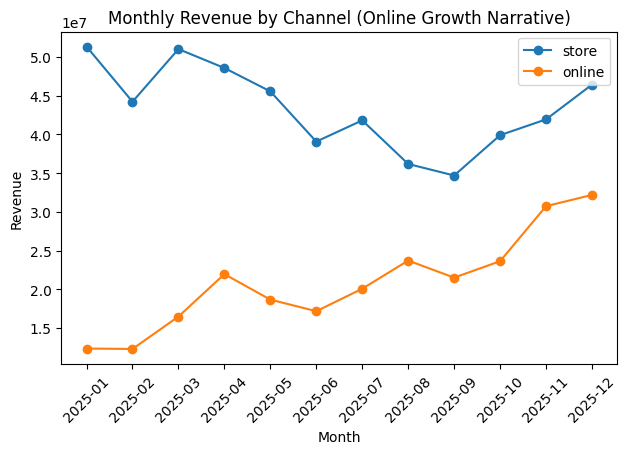

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(pivot.index, pivot.get("store", pd.Series(index=pivot.index, data=0.0)), marker="o")
ax.plot(pivot.index, pivot.get("online", pd.Series(index=pivot.index, data=0.0)), marker="o")
ax.set_title("Monthly Revenue by Channel (Online Growth Narrative)")
ax.set_xlabel("Month"); ax.set_ylabel("Revenue")
ax.legend(["store","online"], loc="best")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


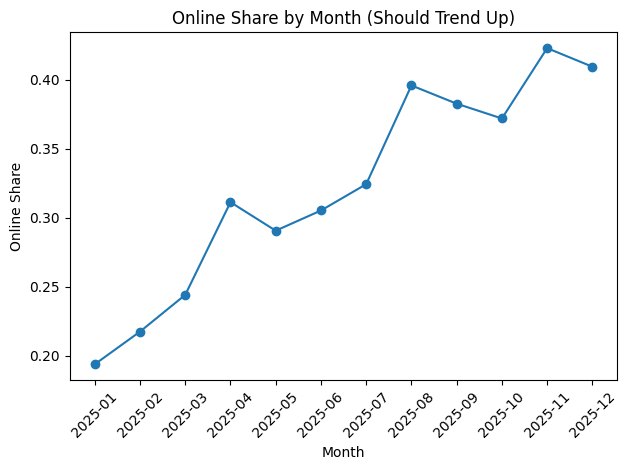

Online share change (pp): 21.56


In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(pivot.index, pivot["online_share"], marker="o")
ax.set_title("Online Share by Month (Should Trend Up)")
ax.set_xlabel("Month"); ax.set_ylabel("Online Share")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Online share change (pp):", round((pivot["online_share"].iloc[-1]-pivot["online_share"].iloc[0])*100, 2))


## D. Discount long-tail + clearance tail

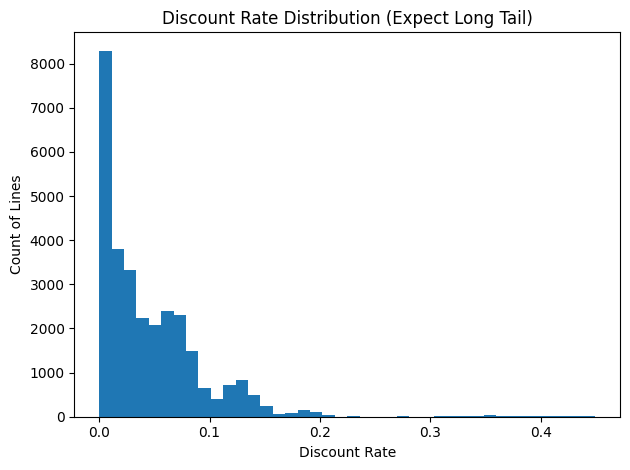

P50: 0.0318
P90: 0.111
P95: 0.1331
P99: 0.19337700000000002
>=0.30 share: 0.00564764068974736


In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.hist(lines["discount"].astype(float), bins=40)
ax.set_title("Discount Rate Distribution (Expect Long Tail)")
ax.set_xlabel("Discount Rate"); ax.set_ylabel("Count of Lines")
plt.tight_layout()
plt.show()

d = lines["discount"].astype(float)
print("P50:", d.quantile(0.50))
print("P90:", d.quantile(0.90))
print("P95:", d.quantile(0.95))
print("P99:", d.quantile(0.99))
print(">=0.30 share:", (d>=0.30).mean())


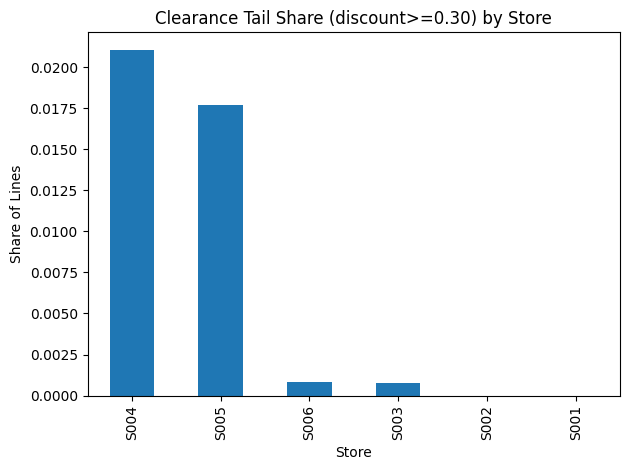

Discount-heavy stores (seeded): ['S004', 'S005']


In [9]:
store_tail = lines[lines["channel_type"]=="store"].groupby("store_id").apply(lambda g: (g["discount"].astype(float) >= 0.30).mean()).sort_values(ascending=False)
fig = plt.figure()
ax = fig.add_subplot(111)
store_tail.plot(kind="bar", ax=ax)
ax.set_title("Clearance Tail Share (discount>=0.30) by Store")
ax.set_xlabel("Store"); ax.set_ylabel("Share of Lines")
plt.tight_layout()
plt.show()

print("Discount-heavy stores (seeded):", sorted(list(discount_heavy_stores)))


## E. Hero SKU concentration (Pareto + top share)

Top 5 share: 0.2972
Top 10 share: 0.4708
Top 20 share: 0.6935


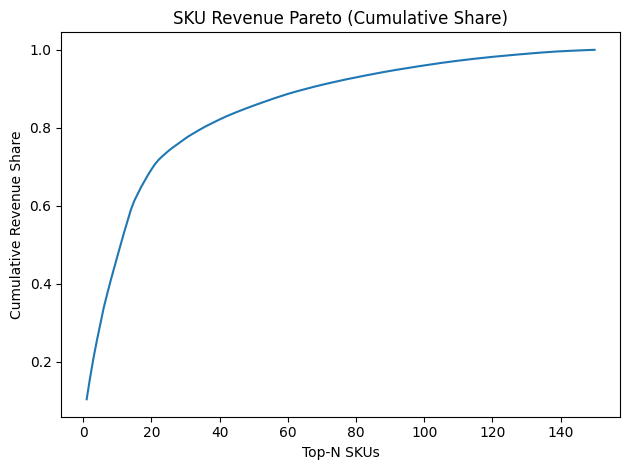

,sku_id,revenue,is_hero_seeded
0,SKU00137,80632593.92,True
1,SKU00143,42568947.97,False
2,SKU00079,39126301.32,False
3,SKU00156,34580768.59,False
4,SKU00014,32387723.20,False
5,SKU00040,32274432.60,False
6,SKU00138,26914574.09,False
7,SKU00142,25824289.87,False
8,SKU00013,24844670.92,False
9,SKU00012,24165686.33,False


In [10]:
sku_rev = lines.groupby("sku_id")["line_total"].sum().sort_values(ascending=False)
total_rev = sku_rev.sum()
print("Top 5 share:", round(sku_rev.head(5).sum()/total_rev, 4))
print("Top 10 share:", round(sku_rev.head(10).sum()/total_rev, 4))
print("Top 20 share:", round(sku_rev.head(20).sum()/total_rev, 4))

cum_share = sku_rev.cumsum() / total_rev
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(np.arange(1, len(cum_share)+1), cum_share.values)
ax.set_title("SKU Revenue Pareto (Cumulative Share)")
ax.set_xlabel("Top-N SKUs"); ax.set_ylabel("Cumulative Revenue Share")
plt.tight_layout()
plt.show()

top = sku_rev.head(25).reset_index().rename(columns={"index":"sku_id","line_total":"revenue"})
top["is_hero_seeded"] = top["sku_id"].isin(hero_skus)
top


## F. Underperforming stores

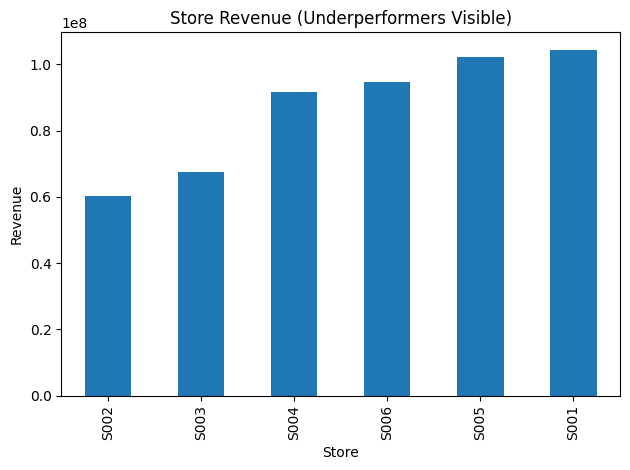

Underperforming stores (seeded): ['S002', 'S003']


In [11]:
store_rev = transactions[transactions["channel_type"]=="store"].groupby("store_id")["total_amount"].sum().sort_values()
fig = plt.figure()
ax = fig.add_subplot(111)
store_rev.plot(kind="bar", ax=ax)
ax.set_title("Store Revenue (Underperformers Visible)")
ax.set_xlabel("Store"); ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()
print("Underperforming stores (seeded):", sorted(list(underperforming_stores)))


## G. Margin erosion proxy (Discount vs GM%)

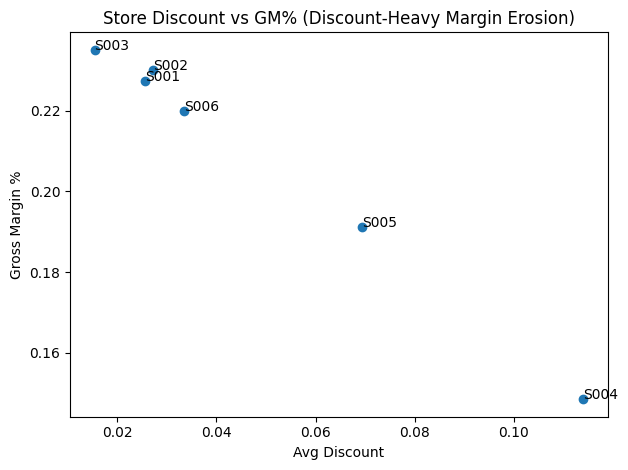

,store_id,revenue,gm,avg_discount,gm_pct
3,S004,9.181577e+07,13625960.86,0.113980,0.148405
4,S005,1.022387e+08,19534888.71,0.069384,0.191071
5,S006,9.461834e+07,20818068.08,0.033407,0.220021
1,S002,6.029424e+07,13882357.85,0.027132,0.230244
0,S001,1.044831e+08,23761940.84,0.025605,0.227424
2,S003,6.741517e+07,15854351.95,0.015421,0.235175


In [12]:
margin_base = {"Fashion": 0.52, "Electronics": 0.18, "Attach & Addons": 0.45}
sku_cost = skus.merge(products[["product_id","category"]], on="product_id", how="left")
sku_cost["margin_base"] = sku_cost["category"].map(margin_base).fillna(0.30)
sku_cost["unit_cost"] = sku_cost["base_price"] * (1.0 - sku_cost["margin_base"])
cost_map = sku_cost.set_index("sku_id")["unit_cost"].to_dict()

m = lines.copy()
m["unit_cost"] = m["sku_id"].map(cost_map).astype(float)
m["cost_total"] = m["unit_cost"] * m["quantity"]
m["revenue"] = m["line_total"].astype(float)
m["gm"] = m["revenue"] - m["cost_total"]
m["gm_pct"] = np.where(m["revenue"]>0, m["gm"]/m["revenue"], np.nan)

store_margin = m[m["channel_type"]=="store"].groupby("store_id").agg(
    revenue=("revenue","sum"),
    gm=("gm","sum"),
    avg_discount=("discount","mean"),
).reset_index()
store_margin["gm_pct"] = np.where(store_margin["revenue"]>0, store_margin["gm"]/store_margin["revenue"], np.nan)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(store_margin["avg_discount"], store_margin["gm_pct"])
for _, r in store_margin.iterrows():
    ax.annotate(r["store_id"], (r["avg_discount"], r["gm_pct"]))
ax.set_title("Store Discount vs GM% (Discount-Heavy Margin Erosion)")
ax.set_xlabel("Avg Discount"); ax.set_ylabel("Gross Margin %")
plt.tight_layout()
plt.show()

store_margin.sort_values("avg_discount", ascending=False)


## H. Returns outliers + reasons

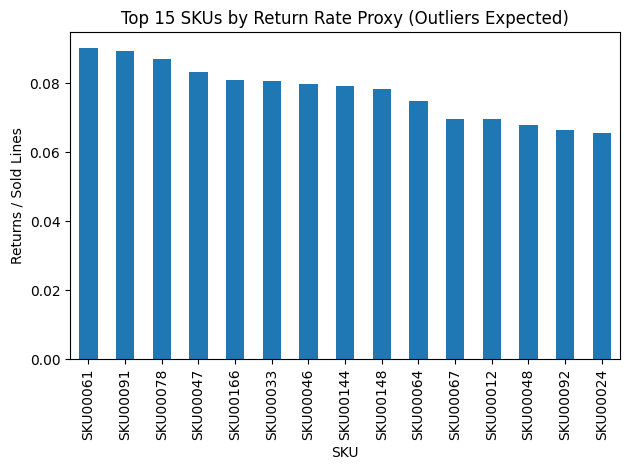

,sku_id,returns,sold_lines,return_rate_proxy,is_high_return_seeded
0,SKU00061,13,144,0.090278,True
1,SKU00091,17,190,0.089474,False
2,SKU00078,19,218,0.087156,True
3,SKU00047,19,228,0.083333,False
4,SKU00166,15,185,0.081081,True
5,SKU00033,18,223,0.080717,True
6,SKU00046,17,213,0.079812,True
7,SKU00144,10,126,0.079365,False
8,SKU00148,9,115,0.078261,False
9,SKU00064,16,214,0.074766,False


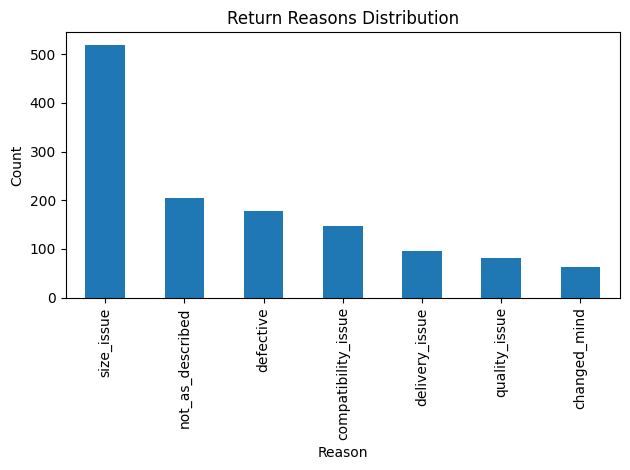

In [13]:
if len(returns)==0:
    print("No returns table found.")
else:
    ret_counts = returns.groupby("sku_id").size().rename("returns")
    sold_counts = lines.groupby("sku_id").size().rename("sold_lines")
    rr = pd.concat([ret_counts, sold_counts], axis=1).fillna(0)
    rr["return_rate_proxy"] = np.where(rr["sold_lines"]>0, rr["returns"]/rr["sold_lines"], 0.0)
    rr = rr.sort_values("return_rate_proxy", ascending=False)
    fig = plt.figure()
    ax = fig.add_subplot(111)
    rr.head(15)["return_rate_proxy"].plot(kind="bar", ax=ax)
    ax.set_title("Top 15 SKUs by Return Rate Proxy (Outliers Expected)")
    ax.set_xlabel("SKU"); ax.set_ylabel("Returns / Sold Lines")
    plt.tight_layout()
    plt.show()

    outliers = rr.head(15).reset_index()
    outliers["is_high_return_seeded"] = outliers["sku_id"].isin(high_return_skus)
    display(outliers)

    reason = returns["return_reason"].value_counts()
    fig = plt.figure()
    ax = fig.add_subplot(111)
    reason.plot(kind="bar", ax=ax)
    ax.set_title("Return Reasons Distribution")
    ax.set_xlabel("Reason"); ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


## I. Quick pass/fail heuristics

In [14]:
assertions = {}

assertions["online_share_delta>=8pp"] = (pivot["online_share"].iloc[-1] - pivot["online_share"].iloc[0]) >= 0.08
assertions["clearance_tail_present>=0.5%"] = (lines["discount"].astype(float) >= 0.30).mean() >= 0.005
top10_share = float(sku_rev.head(10).sum()/sku_rev.sum())
assertions["top10_share>=25%"] = top10_share >= 0.25
assertions["returns_outlier_max>=0.12"] = (rr["return_rate_proxy"].max() >= 0.12) if len(returns) else True

pd.Series(assertions)


online_share_delta>=8pp          True
clearance_tail_present>=0.5%     True
top10_share>=25%                 True
returns_outlier_max>=0.12       False
dtype: bool